<a href="https://colab.research.google.com/github/iras-mpark/MLA1020/blob/main/week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np

# Exmaple of Predictor

### Binary Classification (기계학습 X, Just 예시)



In [ ]:
def simple_binary_classifier(x: np.ndarray) -> int:
  logit = x[0] - x[1] - 1
  if logit > 0:
    predicted_y = 1
  else:
    predicted_y = -1
  return predicted_y

In [ ]:
x_a = np.array([1, 2])
predicted_y_a = simple_binary_classifier(x_a)
print("x_a=", x_a, "-> predicted_y_a=", predicted_y_a)

x_b = np.array([2, 0])
predicted_y_b = simple_binary_classifier(x_b)
print("x_b=", x_b, "-> predicted_y_b=", predicted_y_b)


x_a= [1 2] -> predicted_y_a= -1
x_b= [2 0] -> predicted_y_b= 1


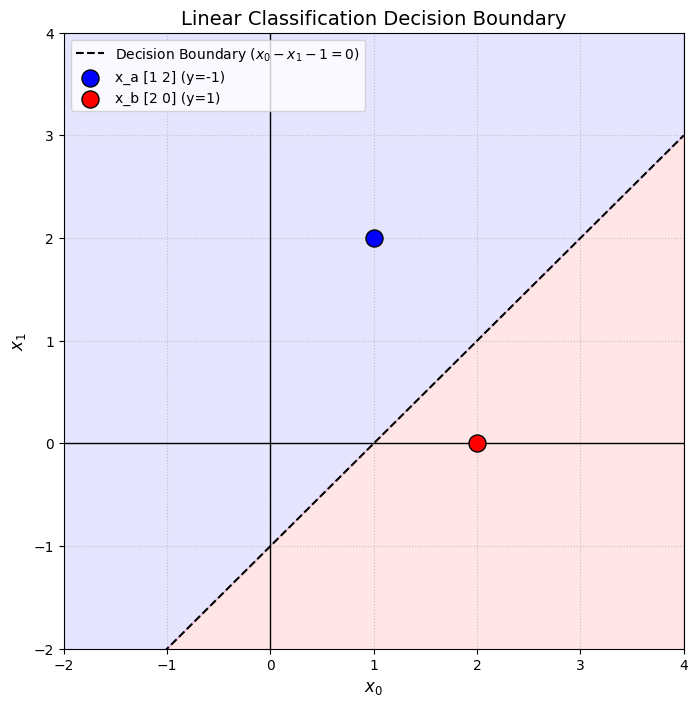

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# 1. 결정 경계선 그리기 (x1 = x0 - 1)
x0_vals = np.linspace(-3, 4, 100)
x1_vals = x0_vals - 1
plt.plot(x0_vals, x1_vals, 'k--', label='Decision Boundary ($x_0 - x_1 - 1 = 0$)')

# 2. 분류 영역 색칠하기
# logit < 0 인 영역 (Predicted: -1, 파란색 영역)
plt.fill_between(x0_vals, x1_vals, 4, color='blue', alpha=0.1)
# logit > 0 인 영역 (Predicted: 1, 빨간색 영역)
plt.fill_between(x0_vals, -4, x1_vals, color='red', alpha=0.1)

# 3. 데이터 포인트 그리기
# x_a: 파란색 원, x_b: 빨간색 원
plt.scatter(x_a[0], x_a[1], color='blue', s=150, edgecolors='black', zorder=5, label=f'x_a {x_a} (y={predicted_y_a})')
plt.scatter(x_b[0], x_b[1], color='red', s=150, edgecolors='black', zorder=5, label=f'x_b {x_b} (y={predicted_y_b})')

# 4. 축 설정 및 꾸미기
plt.axhline(0, color='black', linewidth=1) # x축
plt.axvline(0, color='black', linewidth=1) # y축
plt.xlim(-2, 4)
plt.ylim(-2, 4)
plt.xlabel('$x_0$', fontsize=12)
plt.ylabel('$x_1$', fontsize=12)
plt.title('Linear Classification Decision Boundary', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper left')

# 그래프 출력
plt.show()

### How to set Line(= 기계학습 O)

In [ ]:
class Example:
  x: np.ndarray
  target_y: float

  def __init__(self, x: np.ndarray, target_y: float):
    self.x = x
    self.target_y = target_y

def get_training_data():
  return [
    Example(x=np.array([1, 2]), target_y=-1),
    Example(x=np.array([2, 0]), target_y=1),
    Example(x=np.array([0, 0]), target_y=-1),
  ]

def example_to_point(example: Example) -> dict:
  return {"x0": example.x[0], "x1": example.x[1], "color": "red" if example.target_y == 1 else "blue"}

training_data = get_training_data()

data = [example_to_point(example) for example in training_data]
data

[{'x0': np.int64(1), 'x1': np.int64(2), 'color': 'blue'},
 {'x0': np.int64(2), 'x1': np.int64(0), 'color': 'red'},
 {'x0': np.int64(0), 'x1': np.int64(0), 'color': 'blue'}]

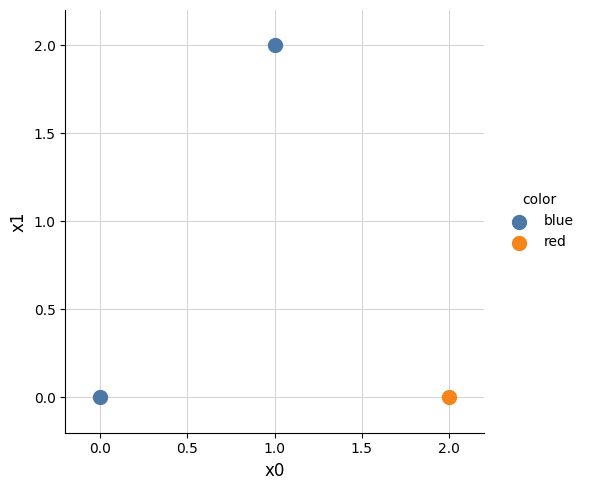

In [ ]:
plt.figure(figsize=(6, 5))

# 범례(Legend)에 색상을 각각 표시하기 위해 데이터를 파란색/빨간색으로 분리
blue_points = [d for d in data if d['color'] == 'blue']
red_points = [d for d in data if d['color'] == 'red']

# 파란색 데이터 포인트 그리기
plt.scatter([d['x0'] for d in blue_points], [d['x1'] for d in blue_points],
            color='#4c78a8', s=100, label='blue', zorder=3)

# 빨간색 데이터 포인트 그리기
plt.scatter([d['x0'] for d in red_points], [d['x1'] for d in red_points],
            color='#f58518', s=100, label='red', zorder=3)

# 축 이름 및 범위 설정 (0.0 ~ 2.0 범위가 잘 보이도록 여백 추가)
plt.xlabel('x0', fontsize=12)
plt.ylabel('x1', fontsize=12)
plt.xlim(-0.2, 2.2)
plt.ylim(-0.2, 2.2)

# 그리드 설정
plt.grid(True, color='lightgray', linestyle='-', linewidth=0.7, zorder=0)

# 범례 설정
plt.legend(title='color', loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# 위쪽 및 오른쪽 테두리 선 숨기기 (깔끔한 시각화를 위해)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# 레이아웃 조정 및 출력
plt.tight_layout()
plt.show()